In [12]:
# STEP 1: Install Dependencies (Google Colab/Jupyter Notebook)
!pip install praw textblob pyspark transformers torch vaderSentiment

In [13]:
# STEP 2: Import Libraries
import praw
import pandas as pd
from textblob import TextBlob
from datetime import datetime
import os
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

In [14]:
# STEP 3: Reddit API Setup
reddit = praw.Reddit(
    client_id="your-client-id",
    client_secret="your-client-secret",
    user_agent="Sentiment Analysis Bot by /u/<your-username>"
)

In [15]:
# STEP 4: Initialize Sentiment Analyzers
vader_analyzer = SentimentIntensityAnalyzer()
bert_analyzer = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [16]:
# STEP 5: Fetch Comments from Reddit
comments = reddit.subreddit("Python").comments(limit=10)
data = []

for comment in comments:
    text = comment.body
    # TextBlob
    tb_score = TextBlob(text).sentiment.polarity
    tb_sentiment = "positive" if tb_score > 0 else "negative" if tb_score < 0 else "neutral"

    # VADER
    vader_score = vader_analyzer.polarity_scores(text)["compound"]
    vader_sentiment = "positive" if vader_score >= 0.05 else "negative" if vader_score <= -0.05 else "neutral"

    # BERT
    try:
        bert_result = bert_analyzer(text[:512])[0]['label'].lower()
        bert_sentiment = "positive" if 'pos' in bert_result else "negative" if 'neg' in bert_result else "neutral"
    except:
        bert_sentiment = "neutral"

    data.append({
        "timestamp": datetime.utcfromtimestamp(comment.created_utc),
        "author": comment.author.name if comment.author else "N/A",
        "comment": text,
        "textblob_sentiment": tb_sentiment,
        "vader_sentiment": vader_sentiment,
        "bert_sentiment": bert_sentiment
    })

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



In [22]:
# STEP 6: Convert to Pandas DataFrame
df_pd = pd.DataFrame(data)
df_pd.to_csv("reddit_sentiments.csv", index=False)
df_pd.head(10)

,timestamp,author,comment,textblob_sentiment,vader_sentiment,bert_sentiment
0,2025-06-02 11:19:19,sue_dee,Pin this comment.,neutral,neutral,positive
1,2025-06-02 11:10:46,predict_addict,Chapter 2 coveres metrics including scale inde...,negative,neutral,negative
2,2025-06-02 10:43:08,Tumortadela,I use nuitka to turn a pyside6 app into a smal...,neutral,neutral,negative
3,2025-06-02 10:32:37,AutoModerator,Your submission has been automatically removed...,positive,positive,negative
4,2025-06-02 10:24:33,AutoModerator,"Hi there, from the /r/Python mods.\n\nWe have ...",positive,positive,negative
5,2025-06-02 09:19:15,AutoModerator,Your submission has been automatically removed...,positive,positive,negative
6,2025-06-02 09:08:32,AutoModerator,Your submission has been automatically removed...,positive,positive,negative
7,2025-06-02 08:45:54,AutoModerator,Your submission has been automatically removed...,positive,positive,negative
8,2025-06-02 08:23:35,nitroll,Because templates are a tool for tool develope...,positive,negative,negative
9,2025-06-02 07:25:36,divyeshaegis12,This is a brilliant LLM approach and encoded v...,positive,positive,positive


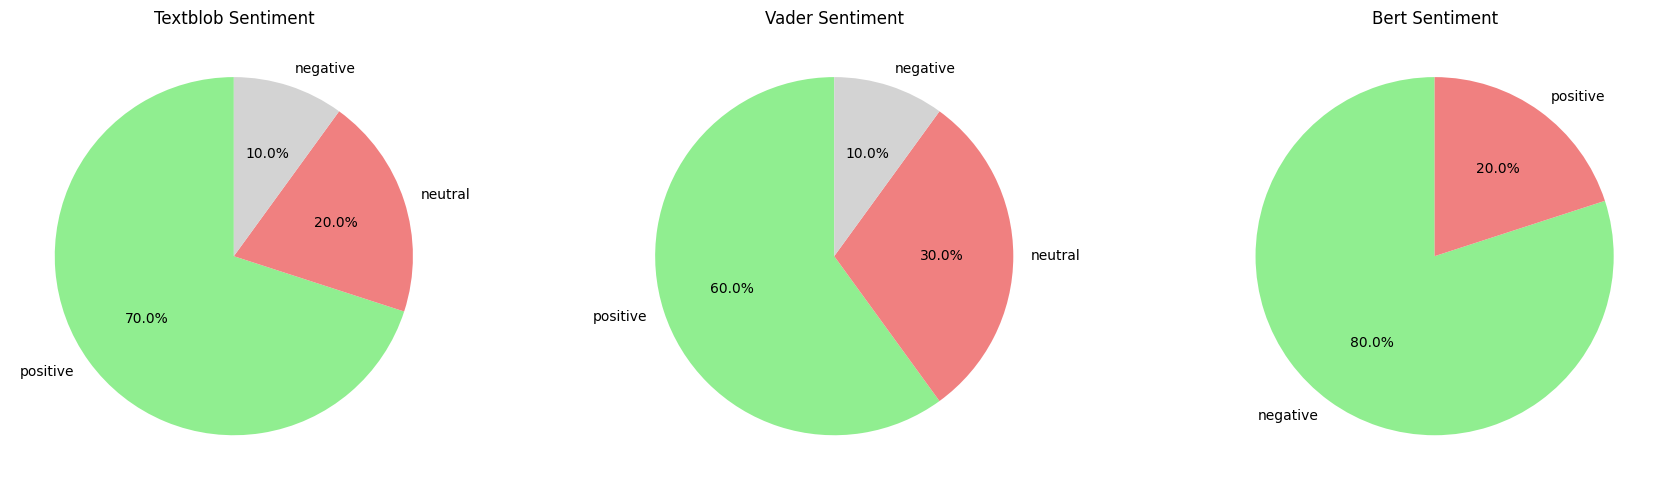

In [18]:
# Pie Charts for Each Model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, ['textblob_sentiment', 'vader_sentiment', 'bert_sentiment']):
    sentiment_counts = df_pd[method].value_counts()
    ax.pie(
        sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightgreen', 'lightcoral', 'lightgrey']
    )
    ax.set_title(f"{method.split('_')[0].capitalize()} Sentiment")

plt.tight_layout()
plt.show()


          TextBlob  VADER  BERT
negative         1      1     8
neutral          2      3     0
positive         7      6     2


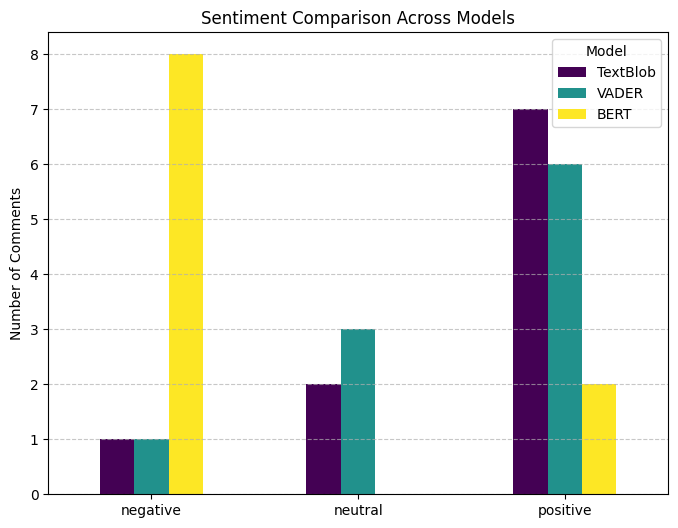

In [19]:
# Bar Chart Comparison
summary = {
    'TextBlob': df_pd['textblob_sentiment'].value_counts(),
    'VADER': df_pd['vader_sentiment'].value_counts(),
    'BERT': df_pd['bert_sentiment'].value_counts()
}

comparison_df = pd.DataFrame(summary).fillna(0).astype(int)
print(comparison_df)

comparison_df.plot(kind='bar', figsize=(8, 6), colormap='viridis')
plt.title("Sentiment Comparison Across Models")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Model")
plt.show()


In [20]:
# Check Agreement Between All Three Models
df_pd['all_agree'] = (
    (df_pd['textblob_sentiment'] == df_pd['vader_sentiment']) &
    (df_pd['vader_sentiment'] == df_pd['bert_sentiment'])
)

agreement_rate = df_pd['all_agree'].mean() * 100
print(f"✅ Agreement between TextBlob, VADER, and BERT: {agreement_rate:.2f}%")


✅ Agreement between TextBlob, VADER, and BERT: 10.00%
